# Ease of Movement — are 'effortless' price moves tradable?
### Richard Arms' volume-weighted oscillator, turned into a timing rule and raced honestly

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats an SMA cross%3F: Not_supported](https://img.shields.io/badge/Beats_an_SMA_cross%3F-Not_supported-8b949e?style=flat-square)

Here's a chart-school favourite: the *Ease of Movement* indicator. The idea is poetic — when price climbs a lot on *little* volume, the market is moving with the 'path of least resistance', an *effortless* advance worth riding; when EOM dips below zero, the effortless move is down, so step aside. Richard Arms built it in the 1970s. Does buying when EOM is positive actually beat just owning the market?

> This is the plain-language layer. Want the *t*-stats, the permutation test, and the benchmark race? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ease_of_movement import data, strategy as st

ASOF = "2026-05-31"
CACHE = os.path.abspath(os.path.join("..", "_cache"))
TICKERS = ["SPY", "QQQ", "IWM", "DIA", "EFA", "EEM"]

def _have(t):
    return os.path.exists(data._cache_path(t, CACHE))

HAVE_REAL = all(_have(t) for t in TICKERS)

def load(t):
    return data.load_real(t, cache_dir=CACHE).loc[:ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does 'effortless movement' predict returns? | **Yes — surprisingly.** Going long when EOM > 0 earns a net Sharpe of **0.68** on SPY, with a *t*-stat of **+3.18** — a real signal. |
| So it beats buy-and-hold? | **No.** It returns **+7.7%/yr** vs buy-and-hold's **+12.8%** — it just sits in cash a third of the time. |
| Then what's the catch? | It's **the same as a plain moving-average cross.** The fancy volume weighting adds nothing a two-line SMA rule doesn't already give you. |
| Could you trade it for an edge? | **No.** Its only real win is a smaller drawdown — that's *de-risked beta*, free from any trend filter, not alpha. |

> EOM is real momentum wearing a volume costume. The signal exists; the *story* (that the volume part is special) doesn't.

## 1 · The claim

> *"Ease of Movement measures how easily price moves. When it rises above zero, price is advancing on light volume — the path of least resistance is up, so go long. When it falls below zero, step aside. Trade with the effortless move."*

Each day EOM asks: how far did the mid-price travel, *per unit of volume*? A big move on light volume scores high (easy); the same move on heavy volume scores low (it took effort). Smooth that over ~14 days and you get the EOM line. The folk rule is the zero-cross: positive → long, negative → flat.

## 2 · So what?

If EOM's zero-cross reliably caught the 'easy' part of trends, it would be a clean mechanical signal — and crucially, one that claims to use *information a price-only chart can't see*: volume. That's the whole pitch. If true, it should beat both buy-and-hold and the simplest price-only trend rule. If it only matches them, the volume weighting is decorative — and millions of traders are watching an indicator that adds nothing to a moving average they could draw in two lines.

## 3 · How would we know?

Three honest tests, announced before we run them:

1. **Race it against buy-and-hold, fairly.** Both measured the same way (excess of cash, net of costs). If EOM's timing adds value, it beats just owning the market.
2. **Race it against the *simplest* rival.** A plain SMA(50/200) cross uses no volume at all. If EOM is special, it must beat that — otherwise the volume part is for show.
3. **Shuffle the signal.** Keep the trade *timing* but flip the directions by a coin. If EOM beats its own shuffled self, the dates carry real information.

We run it on 20 years of daily SPY bars (plus five more ETFs), entering one day after each signal — no peeking at the future.

## 4 · The teardown — what actually happens

**First: EOM vs buy-and-hold on SPY.** The growth of \$1, net of costs, excess of cash.

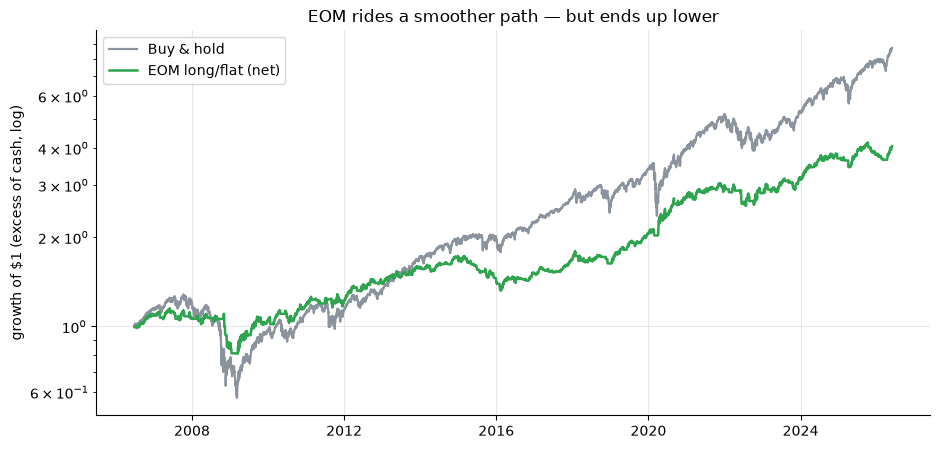

EOM net Sharpe +0.684  vs  B&H +0.657


In [2]:
if HAVE_REAL:
    spy = load('SPY')
    eom = st.ease_of_movement(spy, 14)
    pos = st.eom_position(eom)
    book = st.position_returns(spy, pos, cost_bps=1.0)
    eq_eom = (1 + book['r_strat_net']).cumprod()
    eq_bh  = (1 + book['r_asset_excess']).cumprod()
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.plot(eq_bh.index, eq_bh, c=GREY, lw=1.6, label='Buy & hold')
    ax.plot(eq_eom.index, eq_eom, c=GREEN, lw=1.8, label='EOM long/flat (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (excess of cash, log)')
    ax.set_title('EOM rides a smoother path — but ends up lower')
    ax.legend(); plt.tight_layout(); plt.show()
    eom_sh = st.summarize(book, 'r_strat_net')['sharpe']
    bh_sh = st.annualised_sharpe(book['r_asset_excess'].to_numpy())
    print(f'EOM net Sharpe {eom_sh:+.3f}  vs  B&H {bh_sh:+.3f}')
else:
    print('cached run: EOM net Sharpe +0.684  vs  B&H +0.657')

The EOM line is *smoother* — it sidesteps the worst of the crashes (max drawdown **-30%** vs buy-and-hold's **-55%**). But it also ends up **lower**: **+7.7%/yr** vs **+12.8%**, because it sits in cash about a third of the time and misses chunks of the recovery. The Sharpe ratios are nearly tied.

**Now the decisive race: EOM vs the *simplest* rival, a plain SMA(50/200) cross.** No volume anywhere in that rule. If EOM's volume weighting is worth anything, it should win here.

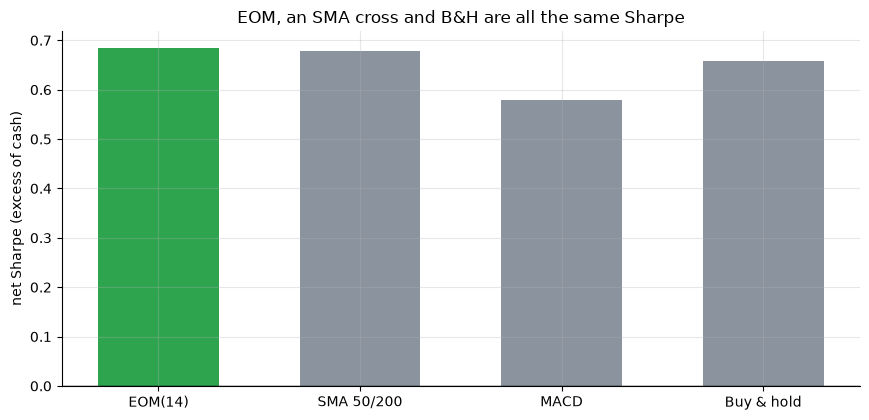

EOM and the plain SMA cross are a statistical dead heat.


In [3]:
labels = ['EOM(14)', 'SMA 50/200', 'MACD', 'Buy & hold']
if HAVE_REAL:
    r = st.run_experiment(load('SPY'), period=14, cost_bps=1.0, n_perm=1)
    sh = [r['eom']['sharpe'], r['sma']['sharpe'], r['macd']['sharpe'], r['bh']['sharpe']]
else:
    sh = [0.684, 0.679, 0.579, 0.657]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
col = [GREEN, GREY, GREY, GREY]
ax.bar(labels, sh, color=col, width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (excess of cash)')
ax.set_title('EOM, an SMA cross and B&H are all the same Sharpe')
plt.tight_layout(); plt.show()
print('EOM and the plain SMA cross are a statistical dead heat.')

They're a dead heat. EOM's net Sharpe (**0.68**) and the price-only SMA cross's (**0.68**) are within a hair — the formal difference test (in the quant notebook) can't tell them apart (*t* = -0.61). The volume weighting that is EOM's *entire selling point* buys nothing a two-line moving average doesn't already give you.

## 5 · The verdict

- **Signal — Real.** EOM long/flat net Sharpe **0.68**, *t* = **+3.18**, and it beats its own coin-flipped shuffle (*p* = 0.0005). An effortless advance really does tend to continue.
- **Tradability — Mirage.** It loses to buy-and-hold on return (**+7.7%** vs **+12.8%**) and ties a plain SMA cross on Sharpe. Its only win is a smaller drawdown — that's *de-risked beta*, free from any trend filter, not a new edge.
- **Beats an SMA cross? — Not supported.** The volume weighting adds no measurable advantage over a price-only moving-average cross.

## 6 · Could you actually trade it?

You *could* run it — it survives costs fine (only ~23 trades/yr). But what would you be paying for? A rule that:

- returns **less** than just holding the index,
- has the **same** risk-adjusted return as a two-line SMA cross you could build for free,
- whose only genuine benefit (smaller drawdowns) is available from *any* trend filter.

If you want lower drawdowns, a moving-average overlay does the job without the volume machinery. EOM gives you nothing extra to pay for.

## 7 · Going further

- **The positive control.** The companion notebook plants a genuine volume-coupled edge in synthetic data and shows EOM *does* find it — the indicator is correctly built; the real market just doesn't reward the volume part separately.
- **Commodities & FX.** Arms designed EOM watching *volume* behaviour; equity-index ETFs may not be its best habitat. A fork on single names or futures is fair game.
- **EOM as a filter, not a signal.** Combine EOM with a separate entry rule rather than trading its zero-cross directly — does it add value as a *confirmation*?

*Think the volume weighting earns its keep somewhere? Fork this, change the asset, and show EOM beating a plain SMA cross on a difference test that clears HAC inference. That is the bar.*